<a href="https://colab.research.google.com/github/MajidSharaf/CampaignLens/blob/main/SentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

!wget "https://raw.githubusercontent.com/MajidSharaf/CampaignLens/main/Datasets/Versions/comments_cleaned.csv"

df = pd.read_csv("/content/comments_cleaned.csv")
print(len(df))
df.head()

--2026-06-01 16:39:20--  https://raw.githubusercontent.com/MajidSharaf/CampaignLens/main/Datasets/Versions/comments_cleaned.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2299025 (2.2M) [text/plain]
Saving to: ‘comments_cleaned.csv’

comments_cleaned.cs 100%[===================>]   2.19M  --.-KB/s    in 0.1s    

2026-06-01 16:39:20 (15.3 MB/s) - ‘comments_cleaned.csv’ saved [2299025/2299025]

22174


,cleaned_text
0,not_want news google
1,trump dumbest president american history terri...
2,fareed know full well reason many objected jcp...
3,china 's xinjiang genocide million visited xin...
4,jet pilot need precision


In [3]:
import numpy as np
from tqdm import tqdm
tqdm.pandas()

In [4]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

Varder is a rule based sentiment analysis tool designed specifically for social media texts, it returns a score for +ve, -ve and netural sentiment


In [6]:
#Defining VADER sentiment function

analyzer = SentimentIntensityAnalyzer()
def getVaderSentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 1   # positive
    elif score <= -0.05:
        return -1  # negative
    else:
        return 0   # neutral

#Applying to all comments
df["Vader"] = df["cleaned_text"].progress_apply(getVaderSentiment)
print(df["Vader"].value_counts())

100%|██████████| 22174/22174 [00:04<00:00, 5465.43it/s]

Vader
 1    10759
-1     6123
 0     5292
Name: count, dtype: int64


VADER classified 48% of comments as positive, 28% as negative, and 24% as neutral. This suggests a generally mixed but slightly positive sentiment across the Trump-related YouTube comments.

In [14]:
from transformers import pipeline

#Loading RoBERTa sentiment model
tweet_model = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    truncation=True,
    max_length=512
)

def getRoBERTaSentiment(text):
    result = tweet_model(text)[0]
    label = result['label']
    if label == 'LABEL_2':
        return 1   # positive
    elif label == 'LABEL_0':
        return -1  # negative
    else:
        return 0   # neutral

#Test on 5 comments first
for i, comment in enumerate(df["cleaned_text"][:5]):
    print(f"Comment {i+1}: {comment}")
    print(f"Sentiment: {getRoBERTaSentiment(comment)}\n")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Comment 1: not_want news google
Sentiment: -1

Comment 2: trump dumbest president american history terrible rollemodel america 's young people nothing violence stupidity lie
Sentiment: -1

Comment 3: fareed know full well reason many objected jcpoa lifting sanction coupled sunset clause put iran world 's foremost sponsor terrorism legal funded path acquiring nuclear weapon pretend issue legitimized islamist regime disengenuous attempt lend credence embarrassment agreement outlived usefulness service no longer required
Sentiment: -1

Comment 4: china 's xinjiang genocide million visited xinjiang not_a single photo trace genocide lying farted zenophobia still blatantly smeared china thousand palesteninians dying hand izrale gennozide farted zealot not_blow wind
Sentiment: -1

Comment 5: jet pilot need precision
Sentiment: 0



In [17]:
#Applying RoBERTa to all comments
df["RoBERTa"] = df["cleaned_text"].progress_apply(getRoBERTaSentiment)
print(df["RoBERTa"].value_counts())

100%|██████████| 22174/22174 [47:15<00:00,  7.82it/s]

RoBERTa
 0    10461
-1     7101
 1     4612
Name: count, dtype: int64


 RoBERTa classified  47% of comments as neutral, 32% as negative, and 21% as positive. This makes sense for a political topic like Trump, most people are either criticizing or staying factual, with fewer genuinely positive comments.

The two models disagreed noticeably, VADER saw 48% positive while RoBERTa saw only 21%. This suggests VADER overestimates positivity by matching individual words, while RoBERTa's deeper contextual understanding picks up on the overall negative or neutral tone of political comments.


A word cloud visualizes the most frequently occurring words in positive and negative comments. Larger words appear more often. We use RoBERTa labels to split comments into positive and negative groups.

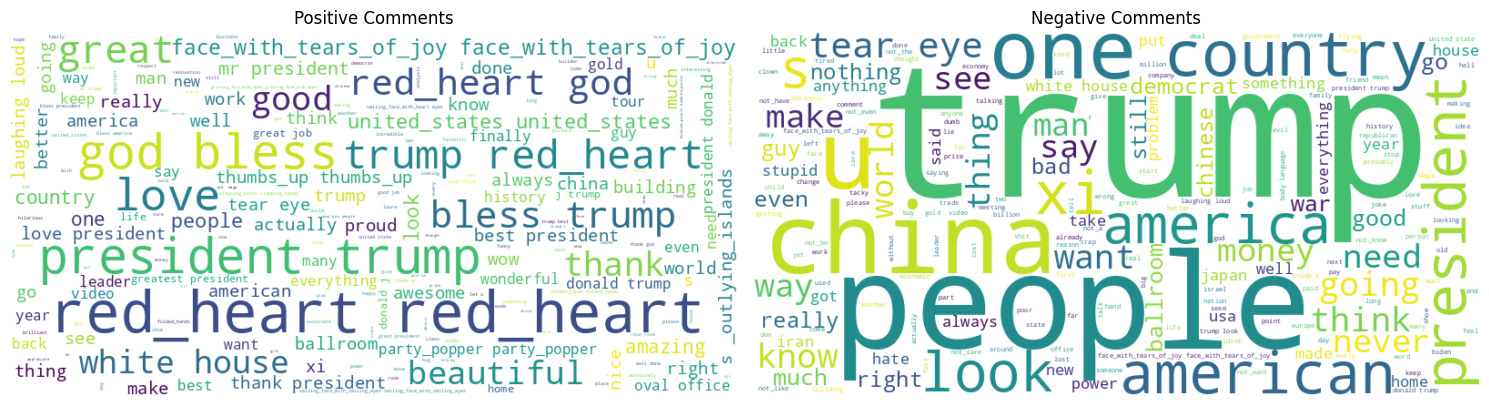

In [18]:
!pip install wordcloud -q
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine positive and negative comments into strings
positive_text = " ".join(df[df["RoBERTa"] == 1]["cleaned_text"])
negative_text = " ".join(df[df["RoBERTa"] == -1]["cleaned_text"])

# Generate wordclouds
def getWordCloud(text):
    return WordCloud(width=800, height=400, background_color="white").generate(text)

# Plot side by side
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.imshow(getWordCloud(positive_text), interpolation="bilinear")
plt.title("Positive Comments")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(getWordCloud(negative_text), interpolation="bilinear")
plt.title("Negative Comments")
plt.axis("off")

plt.tight_layout()
plt.show()

Positive comments are dominated by words like "love", "great", "bless" and "red_heart", reflecting genuine support for Trump. Negative comments tend to include more political topics like "china", "country" and "america", suggesting critics focus more on political issues and policies rather than personal attacks.


In [19]:
#Saving sentiment results
df.to_csv('sentiment_results.csv', index=False)
print("Saved! Shape:", df.shape)
print(df.head())

Saved! Shape: (22174, 3)
                                        cleaned_text  Vader  RoBERTa
0                               not_want news google      0       -1
1  trump dumbest president american history terri...     -1       -1
2  fareed know full well reason many objected jcp...     -1       -1
3  china 's xinjiang genocide million visited xin...     -1       -1
4                           jet pilot need precision      0        0
